In [ ]:
!pip install matplotlib numpy pandas seaborn scikit-learn ipython
!pip install -c conda-forge kneed
!pip install kneed

In [ ]:
import matplotlib.pyplot as plt
from kneed import KneeLocator
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
from mpl_toolkits import mplot3d

In [ ]:
# import csv of imagej analyzed data
df = pd.read_csv("/content/drive/Shareddrives/Summer_2023_VCell_Ml/Summer 2023  Image analysis/param_scan_7-6-23/=7-6_analysis_CSV.csv")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# indexed as[wt_value,min,middle,max]
Param_Vals = {"Ua":[0.03,0.0083,0.02265,0.037],"Ui":[0.07,0.045,0.1425,0.24],
          "Ga":[0.08, 0.075,0.1425,0.21],"Gi":[0.1,0.0227,0.07135,0.12],
          "Ba":[-0.12,-0.138,-0.088,-0.038],"Da":[0.01,0,0.0065,0.013],
          "Di":[0.5,1.75,3]}

Param_List = {"Ua": [], "Ui": [], "Ga": [], "Gi" :[], "Ba": [], "Da": [], "Di": []}

for name in df["File_Name"]: #iterate through al file names
  for param in Param_Vals.keys(): #iterate through all parameter names
    if param in name: #check if parameter name is in file name
      p_i = name.index(param) #get parameter name index
      k = p_i + 3 #index of first number value of parameter
      while k < len(name) and name[k] != ",": #iterate through file name until hitting a comma or the end
        k += 1
      Param_List[param].append(name[p_i+3:k]) #add that value to the parameter list index for that parameter
    else:
      Param_List[param].append(Param_Vals[param][0]) #if the parameter is not in the file name, add the wild-type value to the parameter list

In [ ]:
j = 1
#adds columns for all parameters to the dataframe, can only run once per session
for i in Param_List.keys():
  df.insert(j, i, Param_List[i])
  j+=1
df.head(10)

,File_Name,Ua,Ui,Ga,Gi,Ba,Da,Di,avg_val,num_spots,total_coverage,avg_spot_size,spot_size_std,avg_circ,circ_std
0,"Ba=-0.038,Da=0.0,Di=0.5,Ga=0.075",0.03,0.07,0.075,0.1,-0.038,0.0,0.5,79.2727,724.0,0.326225,1.126500e-08,0.000523,0.713834,0.291812
1,"Ba=-0.038,Da=0.0,Di=0.5,Ga=0.1425",0.03,0.07,0.1425,0.1,-0.038,0.0,0.5,224.3437,1.0,0.923225,2.308062e-05,0.000000,0.541700,0.000000
2,"Ba=-0.038,Da=0.0,Di=0.5,Ga=0.21",0.03,0.07,0.21,0.1,-0.038,0.0,0.5,241.8883,1.0,0.995425,2.488562e-05,0.000000,0.760000,0.000000
3,"Ba=-0.038,Da=0.0,Di=0.5,Gi=0.0227",0.03,0.07,0.08,0.0227,-0.038,0.0,0.5,239.9686,1.0,0.987525,2.468813e-05,0.000000,0.739200,0.000000
4,"Ba=-0.038,Da=0.0,Di=0.5,Gi=0.07135",0.03,0.07,0.08,0.07135,-0.038,0.0,0.5,135.4482,74.0,0.557400,1.883110e-07,0.060858,0.842827,0.243896
5,"Ba=-0.038,Da=0.0,Di=0.5,Gi=0.12",0.03,0.07,0.08,0.12,-0.038,0.0,0.5,75.4394,779.0,0.310450,9.963000e-09,0.000442,0.730863,0.282840
6,"Ba=-0.038,Da=0.0,Di=0.5,Ua=0.0083",0.0083,0.07,0.08,0.1,-0.038,0.0,0.5,157.7047,29.0,0.618450,5.331470e-07,0.111759,0.908231,0.217113
7,"Ba=-0.038,Da=0.0,Di=0.5,Ua=0.02265",0.02265,0.07,0.08,0.1,-0.038,0.0,0.5,118.2180,259.0,0.463600,4.474900e-08,0.008201,0.741222,0.322189
8,"Ba=-0.038,Da=0.0,Di=0.5,Ua=0.037",0.037,0.07,0.08,0.1,-0.038,0.0,0.5,61.7004,766.0,0.313200,1.022200e-08,0.000453,0.726631,0.284944
9,"Ba=-0.038,Da=0.0,Di=0.5,Ui=0.045",0.03,0.045,0.08,0.1,-0.038,0.0,0.5,61.4061,931.0,0.252700,6.786000e-09,0.000273,0.785533,0.248528


In [ ]:
features = df.drop(columns=["File_Name","Ua","Ui","Ga","Gi","Ba","Da","Di","avg_val"]) #]Select the features for normalization
features.head()
features.shape

(2835, 6)

In [ ]:
import tarfile
import urllib

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from PIL import Image

In [ ]:
#we can try other scalers as well to see what worls best
# we can also investigate how the number of compnents affects the results
#we don't necessarily have to use PCA for clustering but it makes it easier to visualize
# preprocessor = Pipeline(
#     [
#         ("scaler", MinMaxScaler()),
#         ("pca", PCA(n_components=2, random_state=42)),
#     ]
# )

# clusterer = Pipeline(
#    [
#        (
#            "kmeans",
#            KMeans(
#                n_clusters=5,
#                init="k-means++",
#                n_init=50,
#                max_iter=500,
#                random_state=42,
#            ),
#        ),
#    ]
# )

# pipe = Pipeline(
#     [
#         ("preprocessor", preprocessor),
#         ("clusterer", clusterer)
#     ]
# )

In [ ]:
scaler = MinMaxScaler() #scale feature data
scaled_features = scaler.fit_transform(features)
scaled_features

kmeans = KMeans(
    init="random",
    n_clusters=3,
    n_init=10,
    max_iter=300,
    random_state=42
)

kmeans.fit(scaled_features)
kmeans.labels_

array([1, 0, 0, ..., 1, 0, 0], dtype=int32)

In [ ]:
df["cluster"] = kmeans.labels_
df.head(10)



,File_Name,Ua,Ui,Ga,Gi,Ba,Da,Di,avg_val,num_spots,total_coverage,avg_spot_size,spot_size_std,avg_circ,circ_std,cluster
0,"Ba=-0.038,Da=0.0,Di=0.5,Ga=0.075",0.03,0.07,0.075,0.1,-0.038,0.0,0.5,79.2727,724.0,0.326225,1.126500e-08,0.000523,0.713834,0.291812,1
1,"Ba=-0.038,Da=0.0,Di=0.5,Ga=0.1425",0.03,0.07,0.1425,0.1,-0.038,0.0,0.5,224.3437,1.0,0.923225,2.308062e-05,0.000000,0.541700,0.000000,0
2,"Ba=-0.038,Da=0.0,Di=0.5,Ga=0.21",0.03,0.07,0.21,0.1,-0.038,0.0,0.5,241.8883,1.0,0.995425,2.488562e-05,0.000000,0.760000,0.000000,0
3,"Ba=-0.038,Da=0.0,Di=0.5,Gi=0.0227",0.03,0.07,0.08,0.0227,-0.038,0.0,0.5,239.9686,1.0,0.987525,2.468813e-05,0.000000,0.739200,0.000000,0
4,"Ba=-0.038,Da=0.0,Di=0.5,Gi=0.07135",0.03,0.07,0.08,0.07135,-0.038,0.0,0.5,135.4482,74.0,0.557400,1.883110e-07,0.060858,0.842827,0.243896,2
5,"Ba=-0.038,Da=0.0,Di=0.5,Gi=0.12",0.03,0.07,0.08,0.12,-0.038,0.0,0.5,75.4394,779.0,0.310450,9.963000e-09,0.000442,0.730863,0.282840,1
6,"Ba=-0.038,Da=0.0,Di=0.5,Ua=0.0083",0.0083,0.07,0.08,0.1,-0.038,0.0,0.5,157.7047,29.0,0.618450,5.331470e-07,0.111759,0.908231,0.217113,2
7,"Ba=-0.038,Da=0.0,Di=0.5,Ua=0.02265",0.02265,0.07,0.08,0.1,-0.038,0.0,0.5,118.2180,259.0,0.463600,4.474900e-08,0.008201,0.741222,0.322189,2
8,"Ba=-0.038,Da=0.0,Di=0.5,Ua=0.037",0.037,0.07,0.08,0.1,-0.038,0.0,0.5,61.7004,766.0,0.313200,1.022200e-08,0.000453,0.726631,0.284944,1
9,"Ba=-0.038,Da=0.0,Di=0.5,Ui=0.045",0.03,0.045,0.08,0.1,-0.038,0.0,0.5,61.4061,931.0,0.252700,6.786000e-09,0.000273,0.785533,0.248528,1


In [ ]:
#PCA
pca = PCA(n_components=2)
pca.fit(scaled_features)
pca_df = pd.DataFrame(pca.transform(scaled_features))
# pca_df.head(10)
df["component_1"] = pca_df[0]
df["component_2"] = pca_df[1]
df.head()
df.shape


(2835, 18)

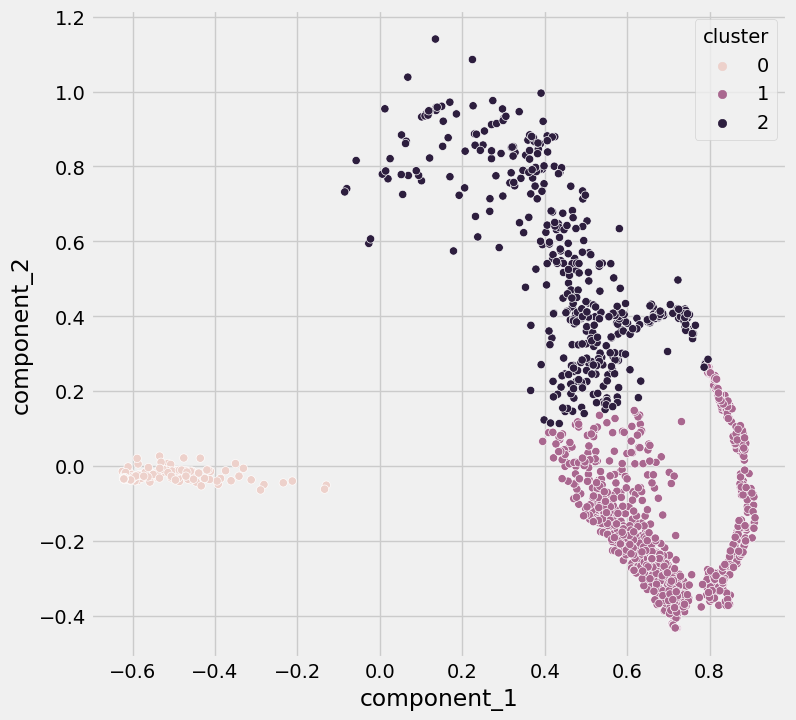

In [ ]:
#visualization
plt.style.use("fivethirtyeight")
plt.figure(figsize=(8, 8))

scat = sns.scatterplot(x = df["component_1"], y=df["component_2"],hue=df["cluster"])


plt.show()

In [ ]:
#3D Visualization

#drop the 2 PCs from original PCA
df_td = df.drop(columns=["component_1","component_2"])
df_td.head()


,File_Name,Ua,Ui,Ga,Gi,Ba,Da,Di,avg_val,num_spots,total_coverage,avg_spot_size,spot_size_std,avg_circ,circ_std,cluster,component_3
0,"Ba=-0.038,Da=0.0,Di=0.5,Ga=0.075",0.03,0.07,0.075,0.1,-0.038,0.0,0.5,79.2727,724.0,0.326225,1.126500e-08,0.000523,0.713834,0.291812,0,0.350731
1,"Ba=-0.038,Da=0.0,Di=0.5,Ga=0.1425",0.03,0.07,0.1425,0.1,-0.038,0.0,0.5,224.3437,1.0,0.923225,2.308062e-05,0.000000,0.541700,0.000000,1,-0.094994
2,"Ba=-0.038,Da=0.0,Di=0.5,Ga=0.21",0.03,0.07,0.21,0.1,-0.038,0.0,0.5,241.8883,1.0,0.995425,2.488562e-05,0.000000,0.760000,0.000000,1,0.017343
3,"Ba=-0.038,Da=0.0,Di=0.5,Gi=0.0227",0.03,0.07,0.08,0.0227,-0.038,0.0,0.5,239.9686,1.0,0.987525,2.468813e-05,0.000000,0.739200,0.000000,1,0.006316
4,"Ba=-0.038,Da=0.0,Di=0.5,Gi=0.07135",0.03,0.07,0.08,0.07135,-0.038,0.0,0.5,135.4482,74.0,0.557400,1.883110e-07,0.060858,0.842827,0.243896,2,-0.027491


In [ ]:
#PCA for 3 components
pca = PCA(n_components=3)
pca.fit(scaled_features)
pca_df = pd.DataFrame(pca.transform(scaled_features))
# pca_df.head(10)
df["component_1"] = pca_df[0]
df["component_2"] = pca_df[1]
df["component_3"] = pca_df[2]
df.head()


,File_Name,Ua,Ui,Ga,Gi,Ba,Da,Di,avg_val,num_spots,total_coverage,avg_spot_size,spot_size_std,avg_circ,circ_std,cluster,component_1,component_2,component_3
0,"Ba=-0.038,Da=0.0,Di=0.5,Ga=0.075",0.03,0.07,0.075,0.1,-0.038,0.0,0.5,79.2727,724.0,0.326225,1.126500e-08,0.000523,0.713834,0.291812,0,0.953129,0.311918,0.442119
1,"Ba=-0.038,Da=0.0,Di=0.5,Ga=0.1425",0.03,0.07,0.1425,0.1,-0.038,0.0,0.5,224.3437,1.0,0.923225,2.308062e-05,0.000000,0.541700,0.000000,1,-0.636474,-0.019384,-0.119746
2,"Ba=-0.038,Da=0.0,Di=0.5,Ga=0.21",0.03,0.07,0.21,0.1,-0.038,0.0,0.5,241.8883,1.0,0.995425,2.488562e-05,0.000000,0.760000,0.000000,1,-0.736001,-0.036464,0.021862
3,"Ba=-0.038,Da=0.0,Di=0.5,Gi=0.0227",0.03,0.07,0.08,0.0227,-0.038,0.0,0.5,239.9686,1.0,0.987525,2.468813e-05,0.000000,0.739200,0.000000,1,-0.724903,-0.035271,0.007962
4,"Ba=-0.038,Da=0.0,Di=0.5,Gi=0.07135",0.03,0.07,0.08,0.07135,-0.038,0.0,0.5,135.4482,74.0,0.557400,1.883110e-07,0.060858,0.842827,0.243896,2,0.670512,0.405322,-0.034654


In [ ]:
print(pca.explained_variance_ratio_) #shows the variance explained by each PC
print(sum(pca.explained_variance_ratio_))

[0.75198297 0.12905067 0.06699032]
0.94802396076019


In [ ]:
features = ["num_spots","total_coverage","avg_spot_size","spot_size_std","avg_circ","circ_std"]
loading_scores = pd.Series(pca.components_[0], index=features) #number indicates PC
sorted_loading_scores = loading_scores.abs().sort_values(ascending=False)

# get the names of the top 10 genes
loading_score_order = sorted_loading_scores[0:6].index.values

## print the gene names and their scores (and +/- sign)
# print(loading_scores)
# print(loading_score_order)
(loading_scores[loading_score_order])

avg_spot_size    -0.767392
total_coverage   -0.558175
circ_std          0.257195
num_spots         0.170126
avg_circ          0.056421
spot_size_std     0.035708
dtype: float64

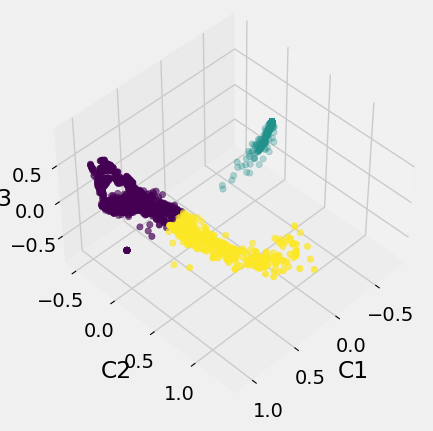

In [ ]:
%matplotlib inline
#3d Plot
fig = plt.figure()
ax = plt.axes(projection='3d')

xdata = df["component_1"]
ydata = df["component_2"]
zdata = df["component_3"]
colors = df["cluster"]

ax.set_xlabel('C1')
ax.set_ylabel('C2')
ax.set_zlabel('C3')

ax.scatter3D(xdata, ydata, zdata, c=colors)
ax.view_init(45, 45)
plt.show()

In [ ]:
df.head()

,File_Name,Ua,Ui,Ga,Gi,Ba,Da,Di,avg_val,num_spots,total_coverage,avg_spot_size,spot_size_std,avg_circ,circ_std,cluster,component_1,component_2,component_3
0,"Ba=-0.038,Da=0.0,Di=0.5,Ga=0.075",0.03,0.07,0.075,0.1,-0.038,0.0,0.5,79.2727,724.0,0.326225,1.126500e-08,0.000523,0.713834,0.291812,0,0.953129,0.311918,0.442119
1,"Ba=-0.038,Da=0.0,Di=0.5,Ga=0.1425",0.03,0.07,0.1425,0.1,-0.038,0.0,0.5,224.3437,1.0,0.923225,2.308062e-05,0.000000,0.541700,0.000000,1,-0.636474,-0.019384,-0.119746
2,"Ba=-0.038,Da=0.0,Di=0.5,Ga=0.21",0.03,0.07,0.21,0.1,-0.038,0.0,0.5,241.8883,1.0,0.995425,2.488562e-05,0.000000,0.760000,0.000000,1,-0.736001,-0.036464,0.021862
3,"Ba=-0.038,Da=0.0,Di=0.5,Gi=0.0227",0.03,0.07,0.08,0.0227,-0.038,0.0,0.5,239.9686,1.0,0.987525,2.468813e-05,0.000000,0.739200,0.000000,1,-0.724903,-0.035271,0.007962
4,"Ba=-0.038,Da=0.0,Di=0.5,Gi=0.07135",0.03,0.07,0.08,0.07135,-0.038,0.0,0.5,135.4482,74.0,0.557400,1.883110e-07,0.060858,0.842827,0.243896,2,0.670512,0.405322,-0.034654


In [ ]:
df1 = df.loc[df["cluster"] == 0] #data frame for each cluster
df2 = df.loc[df["cluster"] == 1]
df3 = df.loc[df["cluster"] == 2]



df1



,File_Name,Ua,Ui,Ga,Gi,Ba,Da,Di,avg_val,num_spots,total_coverage,avg_spot_size,spot_size_std,avg_circ,circ_std,cluster,component_1,component_2
1,"Ba=-0.038,Da=0.0,Di=0.5,Ga=0.1425",0.03,0.07,0.1425,0.1,-0.038,0.0,0.5,224.3437,1.0,0.923225,0.000023,0.0,0.5417,0.0,0,-0.533275,-0.016359
2,"Ba=-0.038,Da=0.0,Di=0.5,Ga=0.21",0.03,0.07,0.21,0.1,-0.038,0.0,0.5,241.8883,1.0,0.995425,0.000025,0.0,0.7600,0.0,0,-0.616664,-0.030774
3,"Ba=-0.038,Da=0.0,Di=0.5,Gi=0.0227",0.03,0.07,0.08,0.0227,-0.038,0.0,0.5,239.9686,1.0,0.987525,0.000025,0.0,0.7392,0.0,0,-0.607365,-0.029767
13,"Ba=-0.038,Da=0.0,Di=1.75,Ga=0.1425",0.03,0.07,0.1425,0.1,-0.038,0.0,1.75,220.9538,1.0,0.909275,0.000023,0.0,0.4928,0.0,0,-0.517542,-0.012332
14,"Ba=-0.038,Da=0.0,Di=1.75,Ga=0.21",0.03,0.07,0.21,0.1,-0.038,0.0,1.75,241.3719,1.0,0.993300,0.000025,0.0,0.7537,0.0,0,-0.614202,-0.030373
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2828,"Ga=0.21,Gi=0.12,Ua=0.0083,Ui=0.24",0.0083,0.24,0.21,0.12,-0.12,0.01,0.5,255.0000,1.0,1.000000,0.000025,0.0,0.7900,0.0,0,-0.621036,-0.034675
2830,"Ga=0.21,Gi=0.12,Ua=0.02265,Ui=0.1425",0.02265,0.1425,0.21,0.12,-0.12,0.01,0.5,255.0000,1.0,1.000000,0.000025,0.0,0.7900,0.0,0,-0.621036,-0.034675
2831,"Ga=0.21,Gi=0.12,Ua=0.02265,Ui=0.24",0.02265,0.24,0.21,0.12,-0.12,0.01,0.5,255.0000,1.0,1.000000,0.000025,0.0,0.7900,0.0,0,-0.621036,-0.034675
2833,"Ga=0.21,Gi=0.12,Ua=0.037,Ui=0.1425",0.037,0.1425,0.21,0.12,-0.12,0.01,0.5,197.0000,1.0,1.000000,0.000025,0.0,0.7900,0.0,0,-0.621036,-0.034675


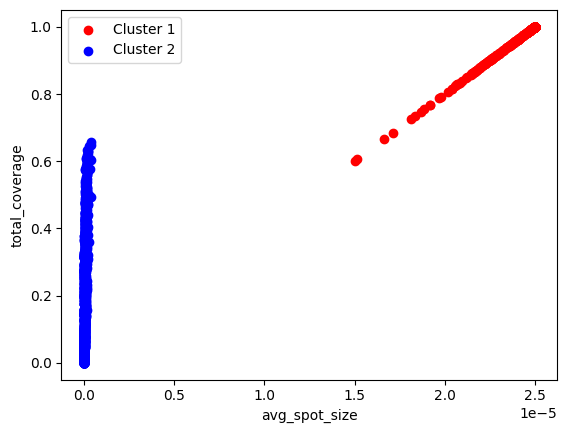

In [ ]:
from matplotlib import style
#plotting clustering against parameters
fig2 = plt.figure()
ax = plt.axes()

x = "avg_spot_size" #set x and y to plot different params and features
y = "total_coverage"

# xdata = df[x]
# ydata = df[y]
# zdata = df["component_3"]
# colors = df["cluster"]

ax.set_xlabel(x)
ax.set_ylabel(y)
# ax.set_zlabel('C3')

ax.scatter(df1[x], df1[y], c="red", label = "Cluster 1")
ax.scatter(df2[x],df2[y],c="blue", label = "Cluster 2")
# ax.scatter(df3[x],df3[y],c="green", label = "Cluster 3")
ax.legend()
# ax.view_init(45, 45)
plt.style.use('default')
plt.show()